# Task 1 Dataset Analysis  -  Instacart Market Basket

Exploratory analysis of the Instacart dataset. Covers data schema, scale, sparsity, product frequency, and reorder behaviour — each result directly informing the preprocessing and modelling steps that follow.

## Google Drive Setup

In [ ]:
from pathlib import Path
from google.colab import drive

# Mount Google Drive so all project files are accessible at /content/drive.
drive.mount('/content/drive')

DRIVE_ROOT = Path('/content/drive/MyDrive/Advanced AI/advanced-ai')

Mounted at /content/drive


## Section 1  -  Imports and Configuration

All imports and path constants are defined here. `RAW_DIR` points to the six raw CSV files.

In [2]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

# Path to the folder containing the six raw Instacart CSV files.
RAW_DIR    = DRIVE_ROOT / 'data' / 'Task 1' / 'raw' / 'InstaCart Dataset'

# Confirm the configured paths and list all files found in the raw data directory.
print('DRIVE_ROOT :', DRIVE_ROOT)
print('RAW_DIR    :', RAW_DIR)
print()
print('RAW_DIR exists:', RAW_DIR.exists())
print('Files in RAW_DIR:')
for f in sorted(RAW_DIR.iterdir()):
    print(f'  {f.name}')

DRIVE_ROOT : /content/drive/MyDrive/Advanced AI/advanced-ai
RAW_DIR    : /content/drive/MyDrive/Advanced AI/advanced-ai/data/Task 1/raw/InstaCart Dataset

RAW_DIR exists: True
Files in RAW_DIR:
  aisles.csv
  departments.csv
  order_products__prior.csv
  order_products__train.csv
  orders.csv
  products.csv


## Section 2  -  Load All CSV Files

Loads all six CSV files and prints the shape, column names, dtypes, and first three rows for each. `low_memory=False` ensures dtype inference runs across the full file rather than per-chunk.

In [3]:
# Names of the six CSV files to load.
csv_files = [
    'aisles.csv',
    'departments.csv',
    'orders.csv',
    'order_products__prior.csv',
    'order_products__train.csv',
    'products.csv',
]

# Load each file into a DataFrame and store it in a dictionary keyed by filename.
dataframes = {}
for fname in csv_files:
    # Read the CSV in full without chunking to ensure correct dtype inference.
    df = pd.read_csv(RAW_DIR / fname, low_memory=False)
    dataframes[fname] = df
    print('=' * 60)
    print(f'File      : {fname}')
    print(f'Shape     : {df.shape[0]:,} rows x {df.shape[1]} columns')
    print(f'Columns   : {list(df.columns)}')
    print('Dtypes:')
    # Print the inferred dtype for each column so schema issues are immediately visible.
    for col, dtype in df.dtypes.items():
        print(f'  {col:<30} {dtype}')
    print('First 3 rows:')
    print(df.head(3).to_string(index=False))
    print()

# Assign each DataFrame to a named variable for easier reference throughout the notebook.
aisles        = dataframes['aisles.csv']
departments   = dataframes['departments.csv']
orders        = dataframes['orders.csv']
order_prior   = dataframes['order_products__prior.csv']
order_train   = dataframes['order_products__train.csv']
products      = dataframes['products.csv']

File      : aisles.csv
Shape     : 134 rows x 2 columns
Columns   : ['aisle_id', 'aisle']
Dtypes:
  aisle_id                       int64
  aisle                          object
First 3 rows:
 aisle_id                 aisle
        1 prepared soups salads
        2     specialty cheeses
        3   energy granola bars

File      : departments.csv
Shape     : 21 rows x 2 columns
Columns   : ['department_id', 'department']
Dtypes:
  department_id                  int64
  department                     object
First 3 rows:
 department_id department
             1     frozen
             2      other
             3     bakery

File      : orders.csv
Shape     : 3,421,083 rows x 7 columns
Columns   : ['order_id', 'user_id', 'eval_set', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order']
Dtypes:
  order_id                       int64
  user_id                        int64
  eval_set                       object
  order_number                   int64
  order_dow        

## Section 3  -  Department and Aisle Audit

Lists all departments and aisles alphabetically, then counts the number of products in each to identify non-food categories that may need to be excluded from the recommendation scope.

In [4]:
# Full department list sorted alphabetically.
print('All departments (sorted alphabetically):')
print('-' * 40)
for _, row in departments.sort_values('department').iterrows():
    print(f'  {row["department_id"]:>3}  {row["department"]}')
print()

# Full aisle list sorted alphabetically.
print('All aisles (sorted alphabetically):')
print('-' * 40)
for _, row in aisles.sort_values('aisle').iterrows():
    print(f'  {row["aisle_id"]:>3}  {row["aisle"]}')
print()

# Count how many products belong to each department.
dept_product_counts = (
    products.groupby('department_id')
    .size()
    .reset_index(name='product_count')
    .merge(departments, on='department_id')   # Join to get the department name.
    .sort_values('product_count', ascending=False)
)
print('Products per department (descending):')
print('-' * 40)
for _, row in dept_product_counts.iterrows():
    print(f'  {row["department_id"]:>3}  {row["department"]:<30}  {row["product_count"]:>6,} products')
print()

# Count how many products belong to each aisle, then show only the top 50.
aisle_product_counts = (
    products.groupby('aisle_id')
    .size()
    .reset_index(name='product_count')
    .merge(aisles, on='aisle_id')   # Join to get the aisle name.
    .sort_values('product_count', ascending=False)
)
print('Top 50 aisles by product count (descending):')
print('-' * 40)
for _, row in aisle_product_counts.head(50).iterrows():
    print(f'  {row["aisle_id"]:>3}  {row["aisle"]:<45}  {row["product_count"]:>6,} products')

All departments (sorted alphabetically):
----------------------------------------
    5  alcohol
   18  babies
    3  bakery
    7  beverages
   14  breakfast
   10  bulk
   15  canned goods
   16  dairy eggs
   20  deli
    9  dry goods pasta
    1  frozen
   17  household
    6  international
   12  meat seafood
   21  missing
    2  other
   13  pantry
   11  personal care
    8  pets
    4  produce
   19  snacks

All aisles (sorted alphabetically):
----------------------------------------
  101  air fresheners candles
   66  asian foods
   82  baby accessories
  102  baby bath body care
   92  baby food formula
    8  bakery desserts
   17  baking ingredients
   97  baking supplies decor
  132  beauty
   27  beers coolers
  127  body lotions soap
  112  bread
   93  breakfast bakery
   48  breakfast bars pastries
   18  bulk dried fruits vegetables
   68  bulk grains rice dried goods
   43  buns rolls
   36  butter
   45  candy chocolate
   99  canned fruit applesauce
   81  canned

## Section 4  -  Orders Overview

Counts the total number of users and orders in the dataset, then analyses how many orders each user has placed. The distribution informs the minimum order threshold used to filter out low-signal users before modelling.

Unique users          : 206,209
Unique orders (total) : 3,421,083
Unique orders (prior) : 3,214,874
Unique orders (train) : 131,209

Orders-per-user summary statistics:
  Mean                 16.6
  Median               10.0
  25th percentile      6.0
  75th percentile      20.0
  Min                  4.0
  Max                  100.0

Users with fewer than  3 orders : 0.0%
Users with fewer than  5 orders : 11.6%
Users with fewer than 10 orders : 46.3%



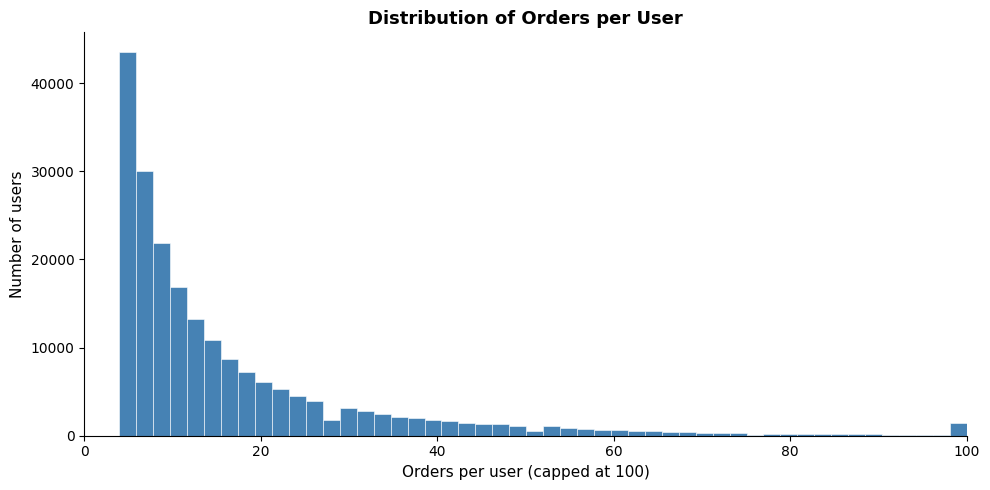

In [5]:
# Count distinct users and orders across the full orders table.
n_users  = orders['user_id'].nunique()
n_orders = orders['order_id'].nunique()

# Count unique orders separately for the prior and train evaluation splits.
n_prior  = order_prior['order_id'].nunique()
n_train  = order_train['order_id'].nunique()

print(f'Unique users          : {n_users:,}')
print(f'Unique orders (total) : {n_orders:,}')
print(f'Unique orders (prior) : {n_prior:,}')
print(f'Unique orders (train) : {n_train:,}')
print()

# Group all orders by user and count how many orders each user has placed.
orders_per_user = orders.groupby('user_id')['order_id'].count()

# Compute descriptive statistics on the orders-per-user distribution.
stats = {
    'Mean'            : orders_per_user.mean(),
    'Median'          : orders_per_user.median(),
    '25th percentile' : orders_per_user.quantile(0.25),
    '75th percentile' : orders_per_user.quantile(0.75),
    'Min'             : orders_per_user.min(),
    'Max'             : orders_per_user.max(),
}
print('Orders-per-user summary statistics:')
for k, v in stats.items():
    print(f'  {k:<20} {v:.1f}')
print()

# Calculate the percentage of users who fall below each order-count threshold.
for threshold in [3, 5, 10]:
    pct = (orders_per_user < threshold).mean() * 100
    print(f'Users with fewer than {threshold:>2} orders : {pct:.1f}%')
print()

# Plot the distribution of orders per user, capped at 100 to avoid extreme outliers stretching the axis.
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(orders_per_user.clip(upper=100), bins=50, edgecolor='white', linewidth=0.4,
        color='steelblue')
ax.set_xlabel('Orders per user (capped at 100)', fontsize=11)
ax.set_ylabel('Number of users', fontsize=11)
ax.set_title('Distribution of Orders per User', fontsize=13, fontweight='bold')
ax.set_xlim(0, 100)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

## Section 5  -  Product Purchase Frequency Analysis

Counts purchases per product across the prior order history. The distribution is long-tailed, so most products are bought rarely — this directly informs the minimum purchase threshold applied during preprocessing.

After joining products     : 32,434,489 rows
After joining aisles       : 32,434,489 rows
After joining departments  : 32,434,489 rows

Purchases-per-product summary statistics:
  Mean                   652.9
  Median                 60.0
  10th percentile        7.0
  25th percentile        17.0
  75th percentile        260.0
  90th percentile        1,021.0
  Max                    472,565.0

Products with fewer than  5 purchases : 4.1%
Products with fewer than 10 purchases : 14.4%
Products with fewer than 25 purchases : 32.2%



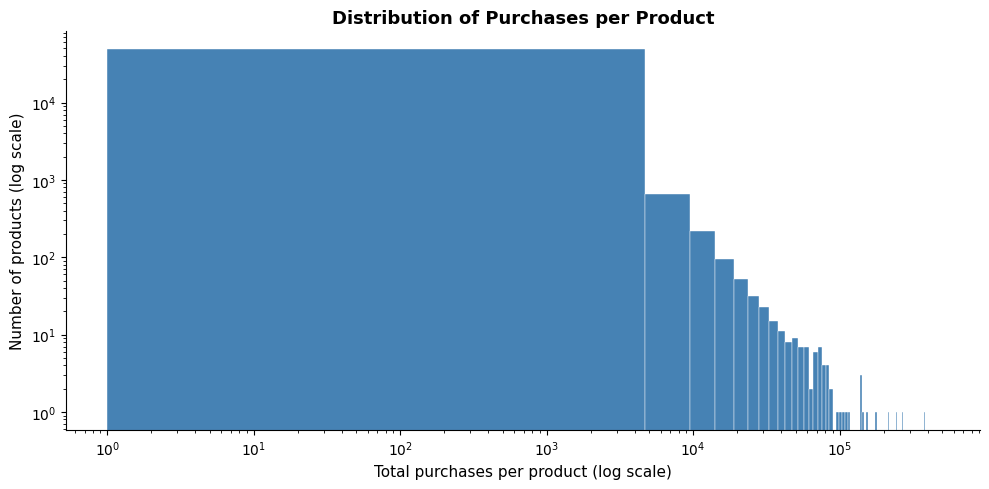

Top 30 most-purchased products:
  Rank   Purchases  Department           Aisle                               Product name
  ----------------------------------------------------------------------------------------------------
  1        472,565  produce              fresh fruits                        Banana
  2        379,450  produce              fresh fruits                        Bag of Organic Bananas
  3        264,683  produce              fresh fruits                        Organic Strawberries
  4        241,921  produce              packaged vegetables fruits          Organic Baby Spinach
  5        213,584  produce              fresh fruits                        Organic Hass Avocado
  6        176,815  produce              fresh fruits                        Organic Avocado
  7        152,657  produce              fresh fruits                        Large Lemon
  8        142,951  produce              fresh fruits                        Strawberries
  9        140,627  produ

In [6]:
# Join order_prior with products, aisles, and departments to get named attributes for each purchase.
merged_prior = order_prior.merge(products,     on='product_id',    how='left')
print(f'After joining products     : {merged_prior.shape[0]:,} rows')

merged_prior = merged_prior.merge(aisles,       on='aisle_id',      how='left')
print(f'After joining aisles       : {merged_prior.shape[0]:,} rows')

merged_prior = merged_prior.merge(departments,  on='department_id', how='left')
print(f'After joining departments  : {merged_prior.shape[0]:,} rows')
print()

# Count total purchases for each product across the entire prior order history.
product_counts = (
    merged_prior.groupby(['product_id', 'product_name', 'aisle', 'department'])
    .size()
    .reset_index(name='purchase_count')
    .sort_values('purchase_count', ascending=False)
)

# Compute summary statistics on the purchases-per-product distribution.
stats_prod = {
    'Mean'             : product_counts['purchase_count'].mean(),
    'Median'           : product_counts['purchase_count'].median(),
    '10th percentile'  : product_counts['purchase_count'].quantile(0.10),
    '25th percentile'  : product_counts['purchase_count'].quantile(0.25),
    '75th percentile'  : product_counts['purchase_count'].quantile(0.75),
    '90th percentile'  : product_counts['purchase_count'].quantile(0.90),
    'Max'              : product_counts['purchase_count'].max(),
}
print('Purchases-per-product summary statistics:')
for k, v in stats_prod.items():
    print(f'  {k:<22} {v:,.1f}')
print()

# Report what fraction of products fall below various purchase count thresholds.
for threshold in [5, 10, 25]:
    pct = (product_counts['purchase_count'] < threshold).mean() * 100
    print(f'Products with fewer than {threshold:>2} purchases : {pct:.1f}%')
print()

# Plot the purchase frequency distribution on log scales to show the long tail clearly.
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(product_counts['purchase_count'], bins=100, edgecolor='white', linewidth=0.3,
        color='steelblue', log=True)
ax.set_xscale('log')
ax.set_xlabel('Total purchases per product (log scale)', fontsize=11)
ax.set_ylabel('Number of products (log scale)', fontsize=11)
ax.set_title('Distribution of Purchases per Product', fontsize=13, fontweight='bold')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

# Print the 30 most-purchased products with their department and aisle context.
print('Top 30 most-purchased products:')
print(f'  {"Rank":<5} {"Purchases":>10}  {"Department":<20} {"Aisle":<35} Product name')
print('  ' + '-' * 100)
for rank, (_, row) in enumerate(product_counts.head(30).iterrows(), start=1):
    print(f'  {rank:<5} {row["purchase_count"]:>10,}  {row["department"]:<20} {row["aisle"]:<35} {row["product_name"]}')

## Section 6  -  User-Item Matrix Sparsity Analysis

Estimates the sparsity of the user-item matrix before and after applying user and product frequency filters. The goal is to identify threshold combinations that reduce matrix size whilst retaining enough interactions for a collaborative filtering model.

In [7]:
# Add user_id to merged_prior by joining on order_id from the orders table.
merged_prior = merged_prior.merge(orders[['order_id', 'user_id']], on='order_id', how='left')

# Count distinct users and products in the full prior dataset before any filtering.
unique_users_prior    = merged_prior['user_id'].nunique()
unique_products_prior = merged_prior['product_id'].nunique()

# The total number of cells in a fully dense user-item matrix.
total_cells  = unique_users_prior * unique_products_prior
# The number of unique user-product pairs that actually appear in the data.
actual_cells = merged_prior.groupby(['user_id', 'product_id']).ngroups
# Sparsity: the fraction of the matrix that is empty (no observed interaction).
sparsity     = 1.0 - actual_cells / total_cells

print('Full prior dataset (no filtering):')
print(f'  Unique users    : {unique_users_prior:,}')
print(f'  Unique products : {unique_products_prior:,}')
print(f'  Total cells     : {total_cells:,}')
print(f'  Filled cells    : {actual_cells:,}')
print(f'  Sparsity        : {sparsity * 100:.4f}%')
print()

# Count how many orders each user has placed, and how many times each product was bought.
user_order_counts   = orders.groupby('user_id')['order_id'].count()
product_buy_counts  = merged_prior.groupby('product_id').size()

user_thresholds    = [5, 10, 20]
product_thresholds = [5, 10, 25]

# Header row for the threshold comparison table.
col_w = 14
header = (
    f'  {"User>=":>{col_w}} {"Prod>=":>{col_w}} {"Users":>{col_w}} '
    f'{"Products":>{col_w}} {"Filled cells":>{col_w}} {"Sparsity":>{col_w}}'
)
print('Sparsity estimates under different filtering thresholds:')
print(header)
print('  ' + '-' * (col_w * 6 + 10))

# Iterate over all combinations of user and product thresholds.
for u_thresh in user_thresholds:
    for p_thresh in product_thresholds:
        # Identify which users and products survive the current thresholds.
        kept_users    = set(user_order_counts[user_order_counts >= u_thresh].index)
        kept_products = set(product_buy_counts[product_buy_counts >= p_thresh].index)

        # Filter the prior interactions to only those users and products.
        filtered = merged_prior[
            merged_prior['user_id'].isin(kept_users) &
            merged_prior['product_id'].isin(kept_products)
        ]

        n_u = filtered['user_id'].nunique()
        n_p = filtered['product_id'].nunique()
        # Count unique user-product pairs in the filtered set.
        n_filled = filtered.groupby(['user_id', 'product_id']).ngroups
        n_total  = n_u * n_p
        sp = (1.0 - n_filled / n_total) * 100 if n_total > 0 else 100.0

        print(
            f'  {u_thresh:>{col_w}} {p_thresh:>{col_w}} {n_u:>{col_w},} '
            f'{n_p:>{col_w},} {n_filled:>{col_w},} {sp:>{col_w}.4f}%'
        )

Full prior dataset (no filtering):
  Unique users    : 206,209
  Unique products : 49,677
  Total cells     : 10,243,844,493
  Filled cells    : 13,307,953
  Sparsity        : 99.8701%

Sparsity estimates under different filtering thresholds:
          User>=         Prod>=          Users       Products   Filled cells       Sparsity
  ----------------------------------------------------------------------------------------------
               5              5        182,223         47,617     12,755,343        99.8530%
               5             10        182,223         42,512     12,727,707        99.8357%
               5             25        182,222         33,696     12,631,389        99.7943%
              10              5        110,728         47,589     10,127,905        99.8078%
              10             10        110,728         42,510     10,106,331        99.7853%
              10             25        110,728         33,696     10,030,310        99.7312%
          

## Section 7  -  Product Name Analysis for TF-IDF Decisions

Builds the product text field used for TF-IDF vectorisation, then analyses its vocabulary to inform decisions about bigram use and custom stop word candidates.

In [8]:
# Attach aisle and department names to the products table to build the text field.
products_full = (
    products
    .merge(aisles,       on='aisle_id',      how='left')
    .merge(departments,  on='department_id', how='left')
)
# Concatenate product name, aisle, and department into a single lowercase string for TF-IDF.
products_full['tfidf_text'] = (
    products_full['product_name'].str.lower() + ' ' +
    products_full['aisle'].str.lower()        + ' ' +
    products_full['department'].str.lower()
)

# Inspect a random sample of the resulting text field to check for anomalies.
print('20 random tfidf_text examples:')
print('-' * 80)
sample = products_full[['product_name', 'tfidf_text']].sample(20, random_state=42)
for _, row in sample.iterrows():
    print(f'  Product : {row["product_name"]}')
    print(f'  Text    : {row["tfidf_text"]}')
    print()

# Tokenise every text field by splitting on whitespace and count all token occurrences.
all_tokens = []
token_counts_per_product = []
for text in products_full['tfidf_text']:
    tokens = text.lower().split()
    all_tokens.extend(tokens)
    # Track how many tokens each product text contributes.
    token_counts_per_product.append(len(tokens))

# Build a frequency map across all tokens in the corpus.
token_freq = Counter(all_tokens)
vocab_size = len(token_freq)

print(f'Total vocabulary size (unique tokens) : {vocab_size:,}')
print(f'Average tokens per product text       : {sum(token_counts_per_product) / len(token_counts_per_product):.2f}')
print()

# Show the most common tokens to identify candidates for a custom stop word list.
print('Top 100 most frequent tokens:')
print('-' * 50)
for rank, (token, count) in enumerate(token_freq.most_common(100), start=1):
    print(f'  {rank:>3}.  {token:<30} {count:>7,}')
print()

# Hapax legomena are tokens that appear only once; they contribute little to TF-IDF quality.
print('Bottom 50 tokens (appearing only once):')
print('-' * 50)
hapax = [tok for tok, cnt in token_freq.items() if cnt == 1]
print(f'  Total hapax legomena: {len(hapax):,}')
for tok in sorted(hapax)[:50]:
    print(f'  {tok}')
print()

# Select the aisle with the most products to examine lexical variation within a single category.
busiest_aisle_row = aisle_product_counts.iloc[0]
busiest_aisle     = busiest_aisle_row['aisle']
busiest_aisle_id  = busiest_aisle_row['aisle_id']

# Sample up to 10 product names from the busiest aisle.
aisle_products = (
    products_full[products_full['aisle_id'] == busiest_aisle_id]['product_name']
    .sample(min(10, len(products_full[products_full['aisle_id'] == busiest_aisle_id])),
            random_state=0)
    .tolist()
)
print(f'10 products from the busiest aisle: "{busiest_aisle}"')
print('-' * 60)
# Print pairs of product names side by side for compact display.
for i in range(0, len(aisle_products), 2):
    left  = aisle_products[i]
    right = aisle_products[i + 1] if i + 1 < len(aisle_products) else ''
    print(f'  {left:<40}  {right}')

20 random tfidf_text examples:
--------------------------------------------------------------------------------
  Product : Mix Popcorn
  Text    : mix popcorn chips pretzels snacks

  Product : Tangerine Lime Drink Tabs
  Text    : tangerine lime drink tabs missing missing

  Product : Fire Roasted Diced Tomatoes With Seasonings
  Text    : fire roasted diced tomatoes with seasonings canned jarred vegetables canned goods

  Product : Soy Curls
  Text    : soy curls chips pretzels snacks

  Product : 4X Ultra Concentrated Natural Laundry Detergent, Free & Clear
  Text    : 4x ultra concentrated natural laundry detergent, free & clear laundry household

  Product : Chocolate Deluxe Bars
  Text    : chocolate deluxe bars energy granola bars snacks

  Product : Stewed Mexican Recipe Sliced Tomatoes
  Text    : stewed mexican recipe sliced tomatoes canned jarred vegetables canned goods

  Product : Chili Con Carne
  Text    : chili con carne frozen meals frozen

  Product : Fruit Squish'em

## Section 8  -  Reorder Behaviour Analysis

Analyses the `reordered` flag in the prior orders to measure how often users purchase the same products again. A high overall reorder rate suggests frequency-based signals are a strong input for the recommendation model.

Overall reorder rate : 58.97%
  (19,126,536 reorders out of 32,434,489 line items)



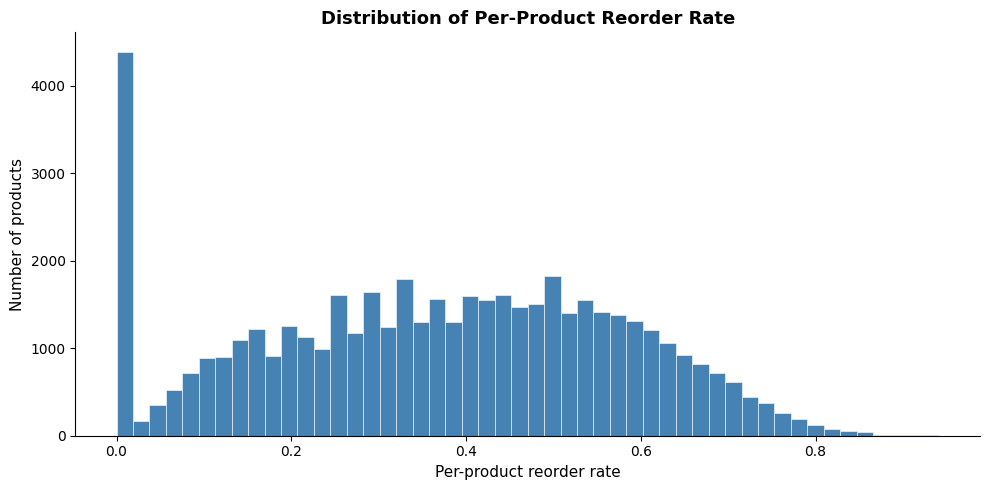

Top 20 products by reorder rate:
------------------------------------------------------------
   1.  0.941  Raw Veggie Wrappers
   2.  0.931  Serenity Ultimate Extrema Overnight Pads
   3.  0.923  Orange Energy Shots
   4.  0.921  Chocolate Love Bar
   5.  0.914  Soy Powder Infant Formula
   6.  0.911  Simply Sleep Nighttime Sleep Aid
   7.  0.909  Energy Shot, Grape Flavor
   8.  0.900  Sparking Water
   9.  0.900  Russian River Valley Reserve Pinot Noir
  10.  0.900  Maca Buttercups
  11.  0.896  Bars Peanut Butter
  12.  0.894  Soy Crisps Lightly Salted
  13.  0.893  Jet Fuel Dark Roast Whole Bean Coffee
  14.  0.892  High Gravity Lager
  15.  0.892  Benchbreak Chardonnay
  16.  0.889  Almond Orgeat Syrup
  17.  0.889  Buttery Spray
  18.  0.885  Organic Blueberry B Mega
  19.  0.885  Beer Can
  20.  0.880  Amazake Almond Shake

Bottom 20 products by reorder rate (lowest reorder rate):
------------------------------------------------------------
   1.  0.000  Organic Herb Mint Livin

In [9]:
# Compute the fraction of line items in the prior set that are reorders.
overall_reorder_rate = order_prior['reordered'].mean() * 100
print(f'Overall reorder rate : {overall_reorder_rate:.2f}%')
print(f'  ({int(order_prior["reordered"].sum()):,} reorders out of {len(order_prior):,} line items)')
print()

# Compute the average reorder rate for each product across all its purchases.
product_reorder = (
    merged_prior.groupby(['product_id', 'product_name'])['reordered']
    .mean()
    .reset_index()
    .rename(columns={'reordered': 'reorder_rate'})
    .sort_values('reorder_rate', ascending=False)
)

# Plot the distribution of per-product reorder rates.
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(product_reorder['reorder_rate'], bins=50, edgecolor='white', linewidth=0.4,
        color='steelblue')
ax.set_xlabel('Per-product reorder rate', fontsize=11)
ax.set_ylabel('Number of products', fontsize=11)
ax.set_title('Distribution of Per-Product Reorder Rate', fontsize=13, fontweight='bold')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

# Show products that users return to most consistently.
print('Top 20 products by reorder rate:')
print('-' * 60)
for rank, (_, row) in enumerate(product_reorder.head(20).iterrows(), start=1):
    print(f'  {rank:>2}.  {row["reorder_rate"]:.3f}  {row["product_name"]}')
print()

# Show products with the lowest reorder rate for contrast.
print('Bottom 20 products by reorder rate (lowest reorder rate):')
print('-' * 60)
for rank, (_, row) in enumerate(product_reorder.tail(20).iterrows(), start=1):
    print(f'  {rank:>2}.  {row["reorder_rate"]:.3f}  {row["product_name"]}')

## Section 9  -  Train Set Ground Truth Analysis

Examines the held-out train orders, focusing on basket size distribution. Basket size directly bounds the maximum achievable recall@k, which affects how evaluation metrics should be interpreted.

Number of users in train set          : 131,209
Total line items in train set         : 1,384,617

Average basket size (train set)       : 10.55 products per order

Basket size summary statistics:
  Mean                   10.6
  Median                 9.0
  25th percentile        5.0
  75th percentile        14.0
  Min                    1.0
  Max                    80.0

Train orders with fewer than  3 products : 10.8%
Train orders with fewer than  5 products : 23.2%
Train orders with fewer than 10 products : 54.7%



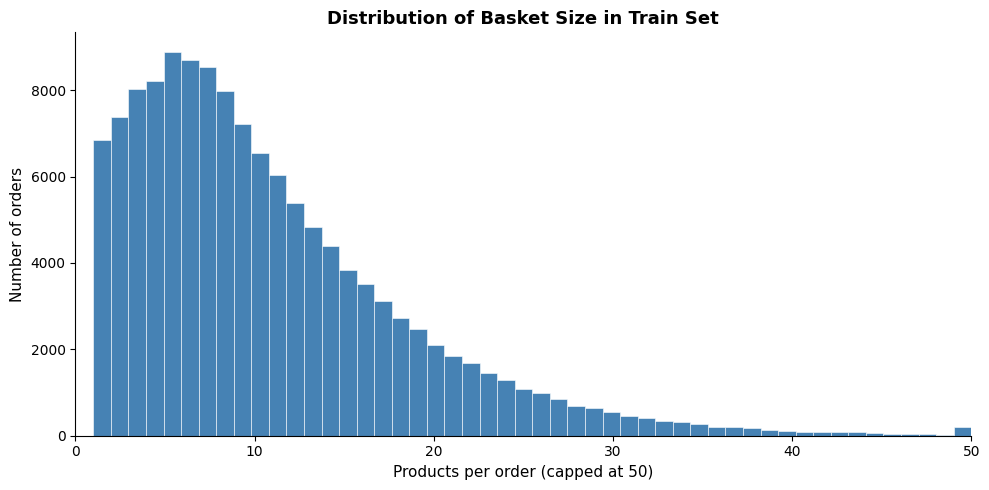

In [10]:
# Count the number of held-out orders in the train set (one per user).
n_train_users = order_train['order_id'].nunique()
print(f'Number of users in train set          : {n_train_users:,}')
print(f'Total line items in train set         : {len(order_train):,}')
print()

# Compute how many products appear in each held-out train order (basket size).
train_basket_sizes = order_train.groupby('order_id').size()
avg_basket = train_basket_sizes.mean()
print(f'Average basket size (train set)       : {avg_basket:.2f} products per order')
print()

# Summary statistics on basket sizes inform how precision@k and recall@k behave.
print('Basket size summary statistics:')
for label, val in [
    ('Mean',            train_basket_sizes.mean()),
    ('Median',          train_basket_sizes.median()),
    ('25th percentile', train_basket_sizes.quantile(0.25)),
    ('75th percentile', train_basket_sizes.quantile(0.75)),
    ('Min',             train_basket_sizes.min()),
    ('Max',             train_basket_sizes.max()),
]:
    print(f'  {label:<22} {val:.1f}')
print()

# Report the fraction of held-out baskets smaller than each size threshold.
for threshold in [3, 5, 10]:
    pct = (train_basket_sizes < threshold).mean() * 100
    print(f'Train orders with fewer than {threshold:>2} products : {pct:.1f}%')
print()

# Plot the distribution of basket sizes, capped at 50 to suppress extreme outliers.
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(train_basket_sizes.clip(upper=50), bins=50, edgecolor='white', linewidth=0.4,
        color='steelblue')
ax.set_xlabel('Products per order (capped at 50)', fontsize=11)
ax.set_ylabel('Number of orders', fontsize=11)
ax.set_title('Distribution of Basket Size in Train Set', fontsize=13, fontweight='bold')
ax.set_xlim(0, 50)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()